In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn import preprocessing

1.DATA CLEANING

In [5]:
data=pd.read_csv("diabet.csv")

In [7]:
data['Gender'] = data['Gender'].map({'F': 0, 'M': 1})

In [8]:
data.drop(columns=['Unnamed: 0'],axis=1,inplace=True)

In [9]:
data.isnull().sum()

,0
Age,0
Gender,1
BMI,0
Chol,0
TG,0
HDL,0
LDL,0
Cr,0
BUN,0
Diagnosis,0


In [10]:
data.dropna(inplace=True)

In [11]:
data

,Age,Gender,BMI,Chol,TG,HDL,LDL,Cr,BUN,Diagnosis
0,50,0.0,24,4.20,0.90,2.40,1.40,46.0,4.70,0
1,26,1.0,23,3.70,1.40,1.10,2.10,62.0,4.50,0
2,33,1.0,21,4.90,1.00,0.80,2.00,46.0,7.10,0
3,45,0.0,21,2.90,1.00,1.00,1.50,24.0,2.30,0
4,50,0.0,24,3.60,1.30,0.90,2.10,50.0,2.00,0
...,...,...,...,...,...,...,...,...,...,...
5127,54,1.0,23,5.00,1.50,1.24,2.98,77.0,3.50,1
5128,50,0.0,22,4.37,2.09,1.37,2.29,47.3,4.40,1
5129,67,1.0,24,3.89,1.38,1.14,2.17,70.6,4.73,1
5130,60,0.0,29,5.91,1.29,1.73,2.85,50.2,7.33,1


In [12]:
data.describe()

,Age,Gender,BMI,Chol,TG,HDL,LDL,Cr,BUN,Diagnosis
count,5131.000000,5131.000000,5131.000000,5131.000000,5131.000000,5131.000000,5131.000000,5131.000000,5131.000000,5131.000000
mean,48.949133,0.634574,24.611772,4.866779,1.719351,1.593303,2.914084,71.152040,4.897124,0.388228
std,14.049909,0.481596,4.276019,1.001122,1.327186,1.038950,0.945512,28.492451,1.689334,0.487395
min,20.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.300000,4.860753,0.500000,0.000000
25%,36.000000,0.000000,22.000000,4.190000,0.910000,1.090000,2.290000,58.000000,3.900000,0.000000
50%,49.000000,1.000000,24.000000,4.800000,1.380000,1.300000,2.790000,70.200000,4.720000,0.000000
75%,59.000000,1.000000,27.000000,5.460000,2.100000,1.590000,3.400000,81.600000,5.600000,1.000000
max,93.000000,1.000000,47.000000,11.650000,32.640000,9.900000,9.900000,800.000000,38.900000,1.000000


2.DATA VISUALIZATION

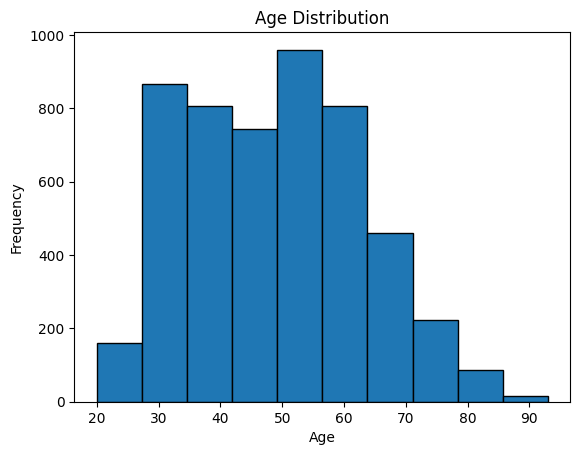

In [13]:
plt.hist(data['Age'], bins=10, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

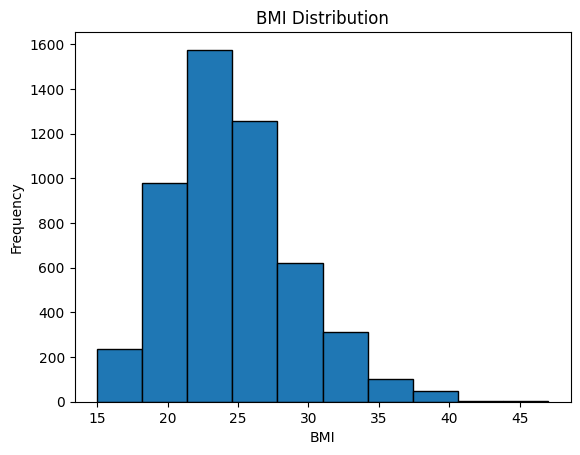

In [14]:
plt.hist(data['BMI'], bins=10, edgecolor='black')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.title('BMI Distribution')
plt.show()

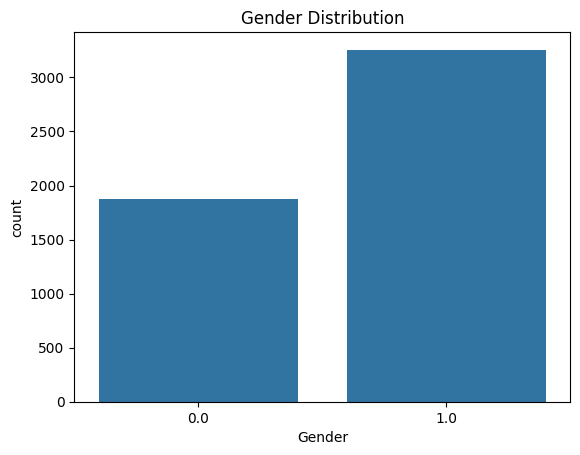

In [15]:
sns.countplot(data=data, x='Gender')
plt.title('Gender Distribution')
plt.show()

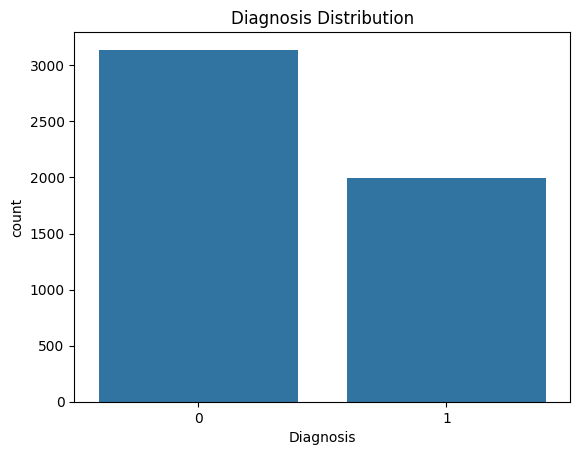

In [16]:
sns.countplot(data=data, x='Diagnosis')
plt.title('Diagnosis Distribution')
plt.show()

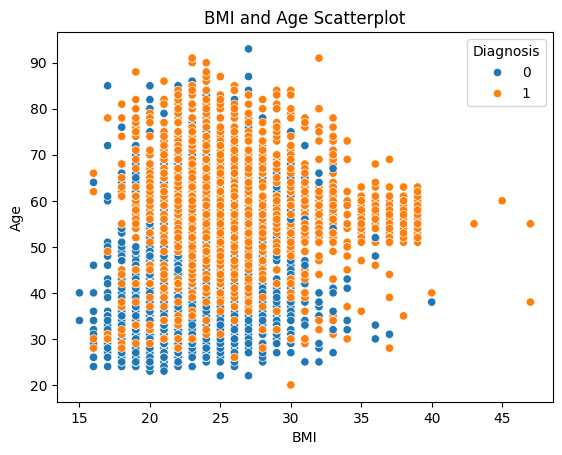

In [17]:
sns.scatterplot(data=data,x="BMI",y="Age" ,hue="Diagnosis")
plt.title('BMI and Age Scatterplot')

plt.show()

3.PREDICTIVE ANALYTICS ALGORITHMS

KNeighborsClassifier Accuracy Test

In [18]:
data_copy =data.copy()
data_copy

,Age,Gender,BMI,Chol,TG,HDL,LDL,Cr,BUN,Diagnosis
0,50,0.0,24,4.20,0.90,2.40,1.40,46.0,4.70,0
1,26,1.0,23,3.70,1.40,1.10,2.10,62.0,4.50,0
2,33,1.0,21,4.90,1.00,0.80,2.00,46.0,7.10,0
3,45,0.0,21,2.90,1.00,1.00,1.50,24.0,2.30,0
4,50,0.0,24,3.60,1.30,0.90,2.10,50.0,2.00,0
...,...,...,...,...,...,...,...,...,...,...
5127,54,1.0,23,5.00,1.50,1.24,2.98,77.0,3.50,1
5128,50,0.0,22,4.37,2.09,1.37,2.29,47.3,4.40,1
5129,67,1.0,24,3.89,1.38,1.14,2.17,70.6,4.73,1
5130,60,0.0,29,5.91,1.29,1.73,2.85,50.2,7.33,1


In [19]:
X = data_copy.drop(columns=['Diagnosis'])

In [20]:
y = data_copy['Diagnosis'].values

In [21]:
knn = KNeighborsClassifier(n_neighbors = 25)
knn.fit(X,y)

KNeighborsClassifier(n_neighbors=25)

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=1,stratify=y)

In [23]:
knn = KNeighborsClassifier(n_neighbors = 23)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=23)

In [24]:
knn.score(X_train,y_train)

0.8140838206627681

In [25]:
knn.score(X_test,y_test)

0.7916260954235638

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [27]:
from sklearn.model_selection import cross_val_score

In [28]:
knn = KNeighborsClassifier(n_neighbors=25)
scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
print(scores.mean())

0.7965426384190849


In [29]:
scores

array([0.77615572, 0.80048662, 0.81265207, 0.78588808, 0.80487805,
       0.81463415, 0.76097561, 0.8097561 , 0.82439024, 0.77560976])

In [30]:
CVAccuracy=[]
for j in range(1,26):
    knn = KNeighborsClassifier(n_neighbors = j)
    scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
    CVAccuracy.append([scores.mean(),j])
data_copy = pd.DataFrame (CVAccuracy,columns=['Validation Accuracy','NeighbourSize'])
print(data_copy)

    Validation Accuracy  NeighbourSize
0              0.760489              1
1              0.753419              2
2              0.772898              3
3              0.764133              4
4              0.780705              5
5              0.777054              6
6              0.790695              7
7              0.788260              8
8              0.791181              9
9              0.782165             10
10             0.790210             11
11             0.787770             12
12             0.791181             13
13             0.788505             14
14             0.791184             15
15             0.789716             16
16             0.792882             17
17             0.795805             18
18             0.796293             19
19             0.793372             20
20             0.794590             21
21             0.794831             22
22             0.795809             23
23             0.792399             24
24             0.796543  

In [31]:
kfoldCV = data_copy.groupby("NeighbourSize")
kfoldCV = kfoldCV.mean()
kfoldCV = kfoldCV.reset_index()
kfoldCV[['NeighbourSize', 'Validation Accuracy']]

,NeighbourSize,Validation Accuracy
0,1,0.760489
1,2,0.753419
2,3,0.772898
3,4,0.764133
4,5,0.780705
5,6,0.777054
6,7,0.790695
7,8,0.788260
8,9,0.791181
9,10,0.782165


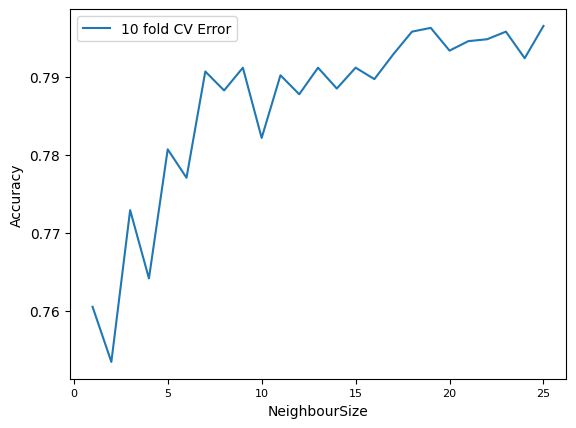

In [32]:
fig=plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(kfoldCV['NeighbourSize'].values,kfoldCV['Validation Accuracy'].values,label = '10 fold CV Error')
ax.set_xlabel('NeighbourSize')
ax.set_ylabel('Accuracy')
ax.tick_params(axis='x', labelsize=8)
ax.legend(loc='best')

In [33]:
knn = KNeighborsClassifier(n_neighbors=25)
knn.fit(X_train,y_train)
knn.score(X_test,y_test)

0.7945472249269717

DecisionTreeClassifier Accuracy Test

In [34]:
data_copy2=data.copy()
data_copy2

,Age,Gender,BMI,Chol,TG,HDL,LDL,Cr,BUN,Diagnosis
0,50,0.0,24,4.20,0.90,2.40,1.40,46.0,4.70,0
1,26,1.0,23,3.70,1.40,1.10,2.10,62.0,4.50,0
2,33,1.0,21,4.90,1.00,0.80,2.00,46.0,7.10,0
3,45,0.0,21,2.90,1.00,1.00,1.50,24.0,2.30,0
4,50,0.0,24,3.60,1.30,0.90,2.10,50.0,2.00,0
...,...,...,...,...,...,...,...,...,...,...
5127,54,1.0,23,5.00,1.50,1.24,2.98,77.0,3.50,1
5128,50,0.0,22,4.37,2.09,1.37,2.29,47.3,4.40,1
5129,67,1.0,24,3.89,1.38,1.14,2.17,70.6,4.73,1
5130,60,0.0,29,5.91,1.29,1.73,2.85,50.2,7.33,1


In [35]:
X = data_copy2[['TG','BMI']]
y = data_copy2['Diagnosis']

In [36]:
X_train, X_test , y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1,stratify=y)

In [37]:
DecisionTreeClassifier()

DecisionTreeClassifier()

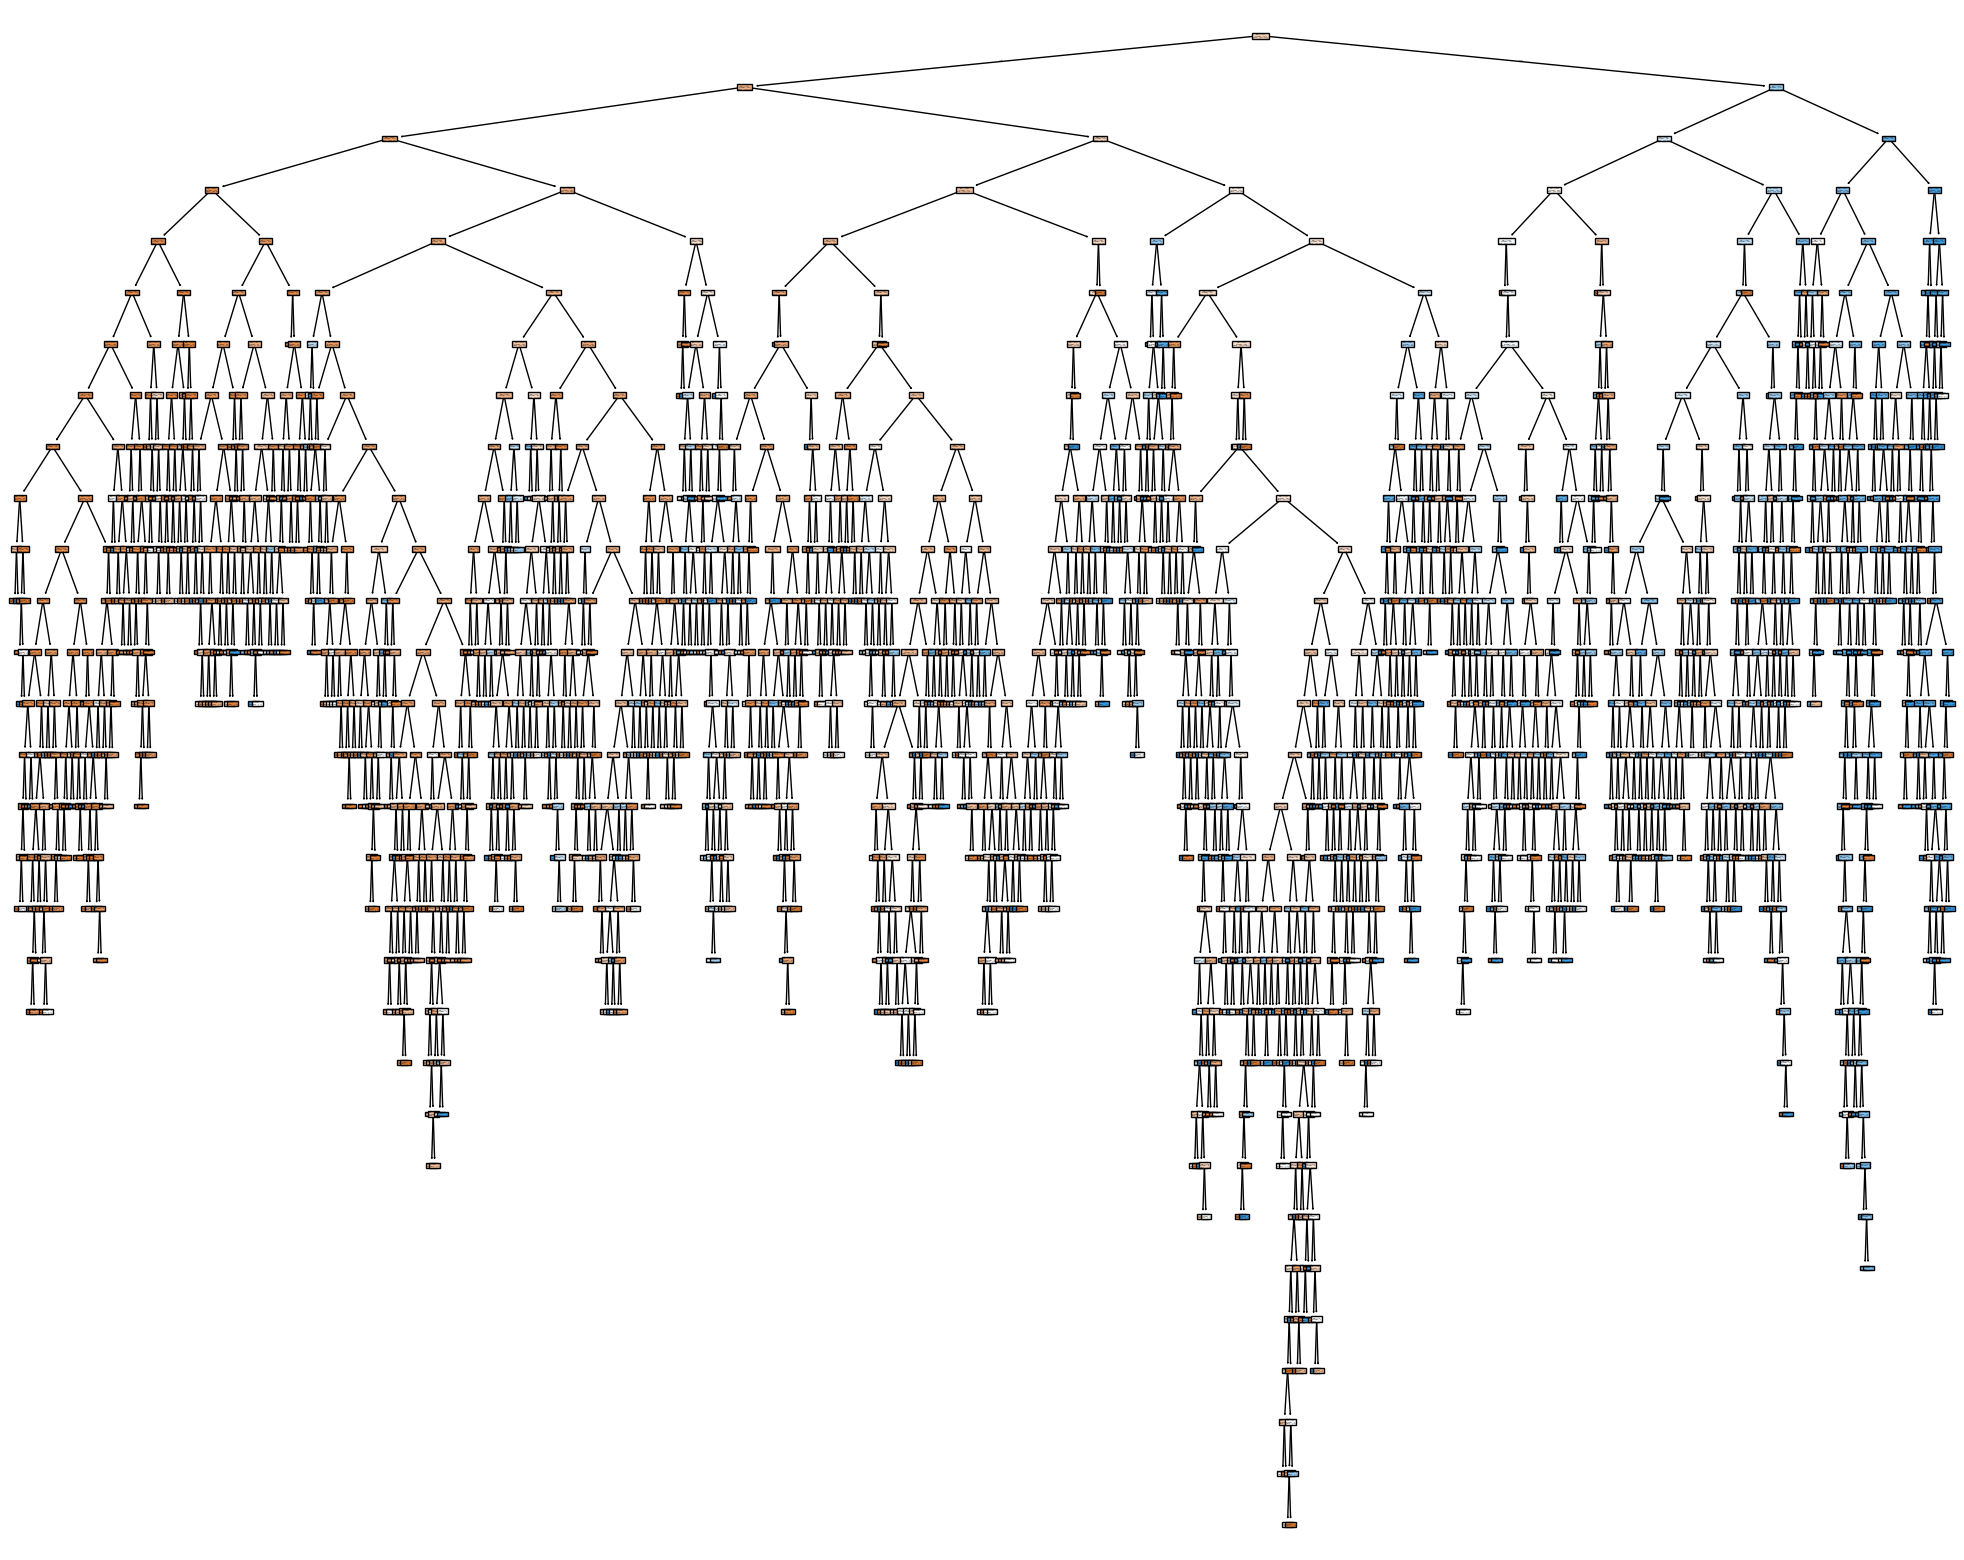

In [38]:
classifier = DecisionTreeClassifier()
classifier.fit(X_train, y_train)
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(classifier, feature_names=['TG','BMI'], filled=True)

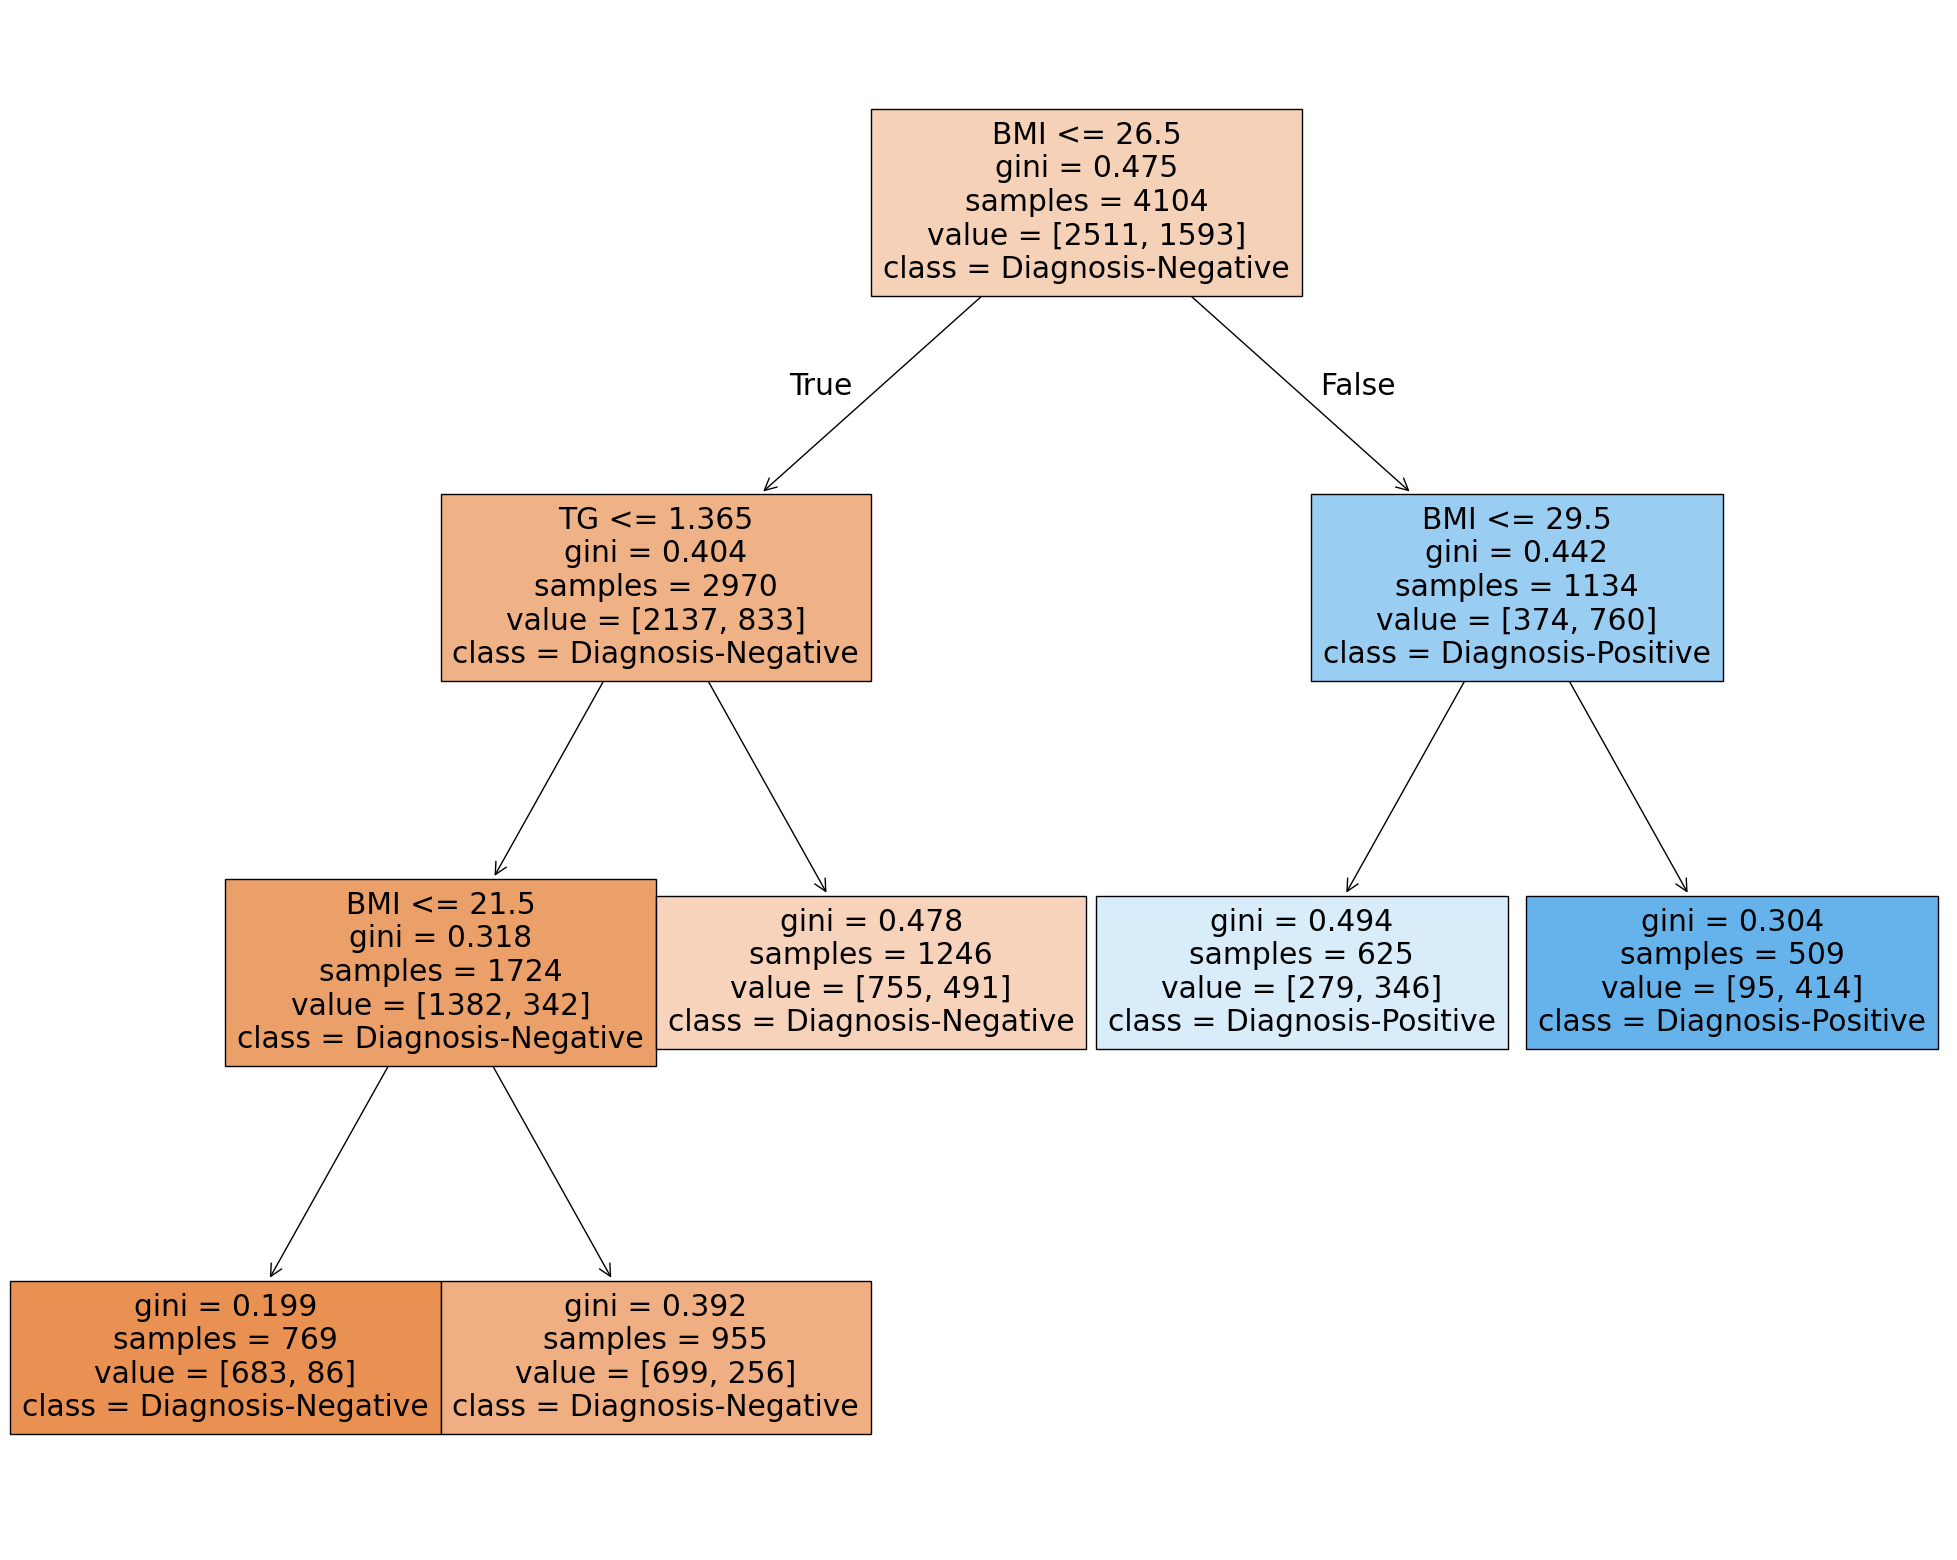

In [39]:
classifier = DecisionTreeClassifier(ccp_alpha=0.005)
classifier.fit(X_train, y_train)
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(classifier, class_names=['Diagnosis-Negative','Diagnosis-Positive'],feature_names=['TG','BMI'], filled=True)

In [40]:
y_pred = classifier.predict(X_test)
accuracy_score(y_test,y_pred)

0.7098344693281402

In [41]:
comp=pd.DataFrame({'Actual':y_test, 'Predicted':y_pred})
comp = pd.concat([X_test.reset_index(drop=True), comp.reset_index(drop=True)], axis= 1)
comp

,TG,BMI,Actual,Predicted
0,3.70,27,0,1
1,1.53,20,0,0
2,1.31,23,0,0
3,1.61,27,0,1
4,3.98,28,1,1
...,...,...,...,...
1022,3.99,29,1,1
1023,2.33,25,1,0
1024,2.00,35,1,1
1025,1.45,21,0,0


In [42]:
y_predprobs = classifier.predict_proba(X_test)
y_predprobs

array([[0.4464    , 0.5536    ],
       [0.605939  , 0.394061  ],
       [0.73193717, 0.26806283],
       ...,
       [0.18664047, 0.81335953],
       [0.605939  , 0.394061  ],
       [0.88816645, 0.11183355]])

In [43]:
classifier = DecisionTreeClassifier()
path = classifier.cost_complexity_pruning_path(X_train, y_train)
path

{'ccp_alphas': array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 5.80154089e-07,
        1.47675586e-06, 1.58223842e-06, 2.70738575e-06, 5.80154089e-06,
        5.80154089e-06, 5.80154089e-06, 5.80154089e-06, 5.80154089e-06,
        6.64540138e-06, 6.76846437e-06, 6.96184907e-06, 6.96184907e-06,
        8.12215724e-06, 8.12215724e-06, 8.12215724e-06, 8.70231133e-06,
        8.70231133e-06, 1.21832359e-05, 1.23766206e-05, 1.35369287e-05,
        1.35369287e-05, 1.54707757e-05, 1.54707757e-05, 1.62443145e-05,
        1.62443145e-05, 1.62443145e-05, 1.62443145e-05, 1.62443145e-05,
        1.62443145e-05, 1.62443145e-05, 1.62443145

In [44]:
from sklearn.model_selection import KFold
cv = KFold(n_splits=5, random_state=10, shuffle=True)
CVErrors=[]
for i in path.ccp_alphas:
    for train_index, validation_index in cv.split(X_train):
        X_trainp, X_valid = X_train.iloc[train_index], X_train.iloc[validation_index]
        y_trainp, y_valid = y_train.iloc[train_index], y_train.iloc[validation_index]
        classifier = DecisionTreeClassifier(ccp_alpha=i)
        classifier.fit(X_trainp, y_trainp)
        y_pred=classifier.predict(X_valid)
        CVErrors.append([i,accuracy_score(y_trainp, classifier.predict(X_trainp)),accuracy_score(y_valid, y_pred)])
data_copy2 = pd.DataFrame(CVErrors,columns=['alpha','Training Accuracy','Validation Accuracy'])
kfoldCV_by_alpha = data_copy2.groupby('alpha')
kfoldCV_by_alpha = kfoldCV_by_alpha.mean()
kfoldCV_by_alpha = kfoldCV_by_alpha.reset_index()
kfoldCV_by_alpha

,alpha,Training Accuracy,Validation Accuracy
0,0.000000e+00,0.887914,0.683672
1,5.801541e-07,0.887914,0.683470
2,1.476756e-06,0.887914,0.684446
3,1.582238e-06,0.887914,0.684689
4,2.707386e-06,0.887914,0.684446
...,...,...,...
388,2.370960e-03,0.705896,0.700768
389,5.066872e-03,0.704860,0.701987
390,9.224660e-03,0.704860,0.701987
391,1.349700e-02,0.704860,0.701987


In [45]:
kfoldCV_by_alpha=kfoldCV_by_alpha.sort_values(by=['Validation Accuracy'],ascending=False)
kfoldCV_by_alpha

,alpha,Training Accuracy,Validation Accuracy
379,0.000782,0.724537,0.703206
381,0.000842,0.720455,0.702718
377,0.000740,0.726059,0.702475
378,0.000745,0.726059,0.702475
376,0.000719,0.726059,0.702475
...,...,...,...
170,0.000132,0.884320,0.679086
162,0.000126,0.884624,0.678842
137,0.000104,0.886330,0.678842
176,0.000137,0.883711,0.678841


Test Accuracy: 0.7166504381694255


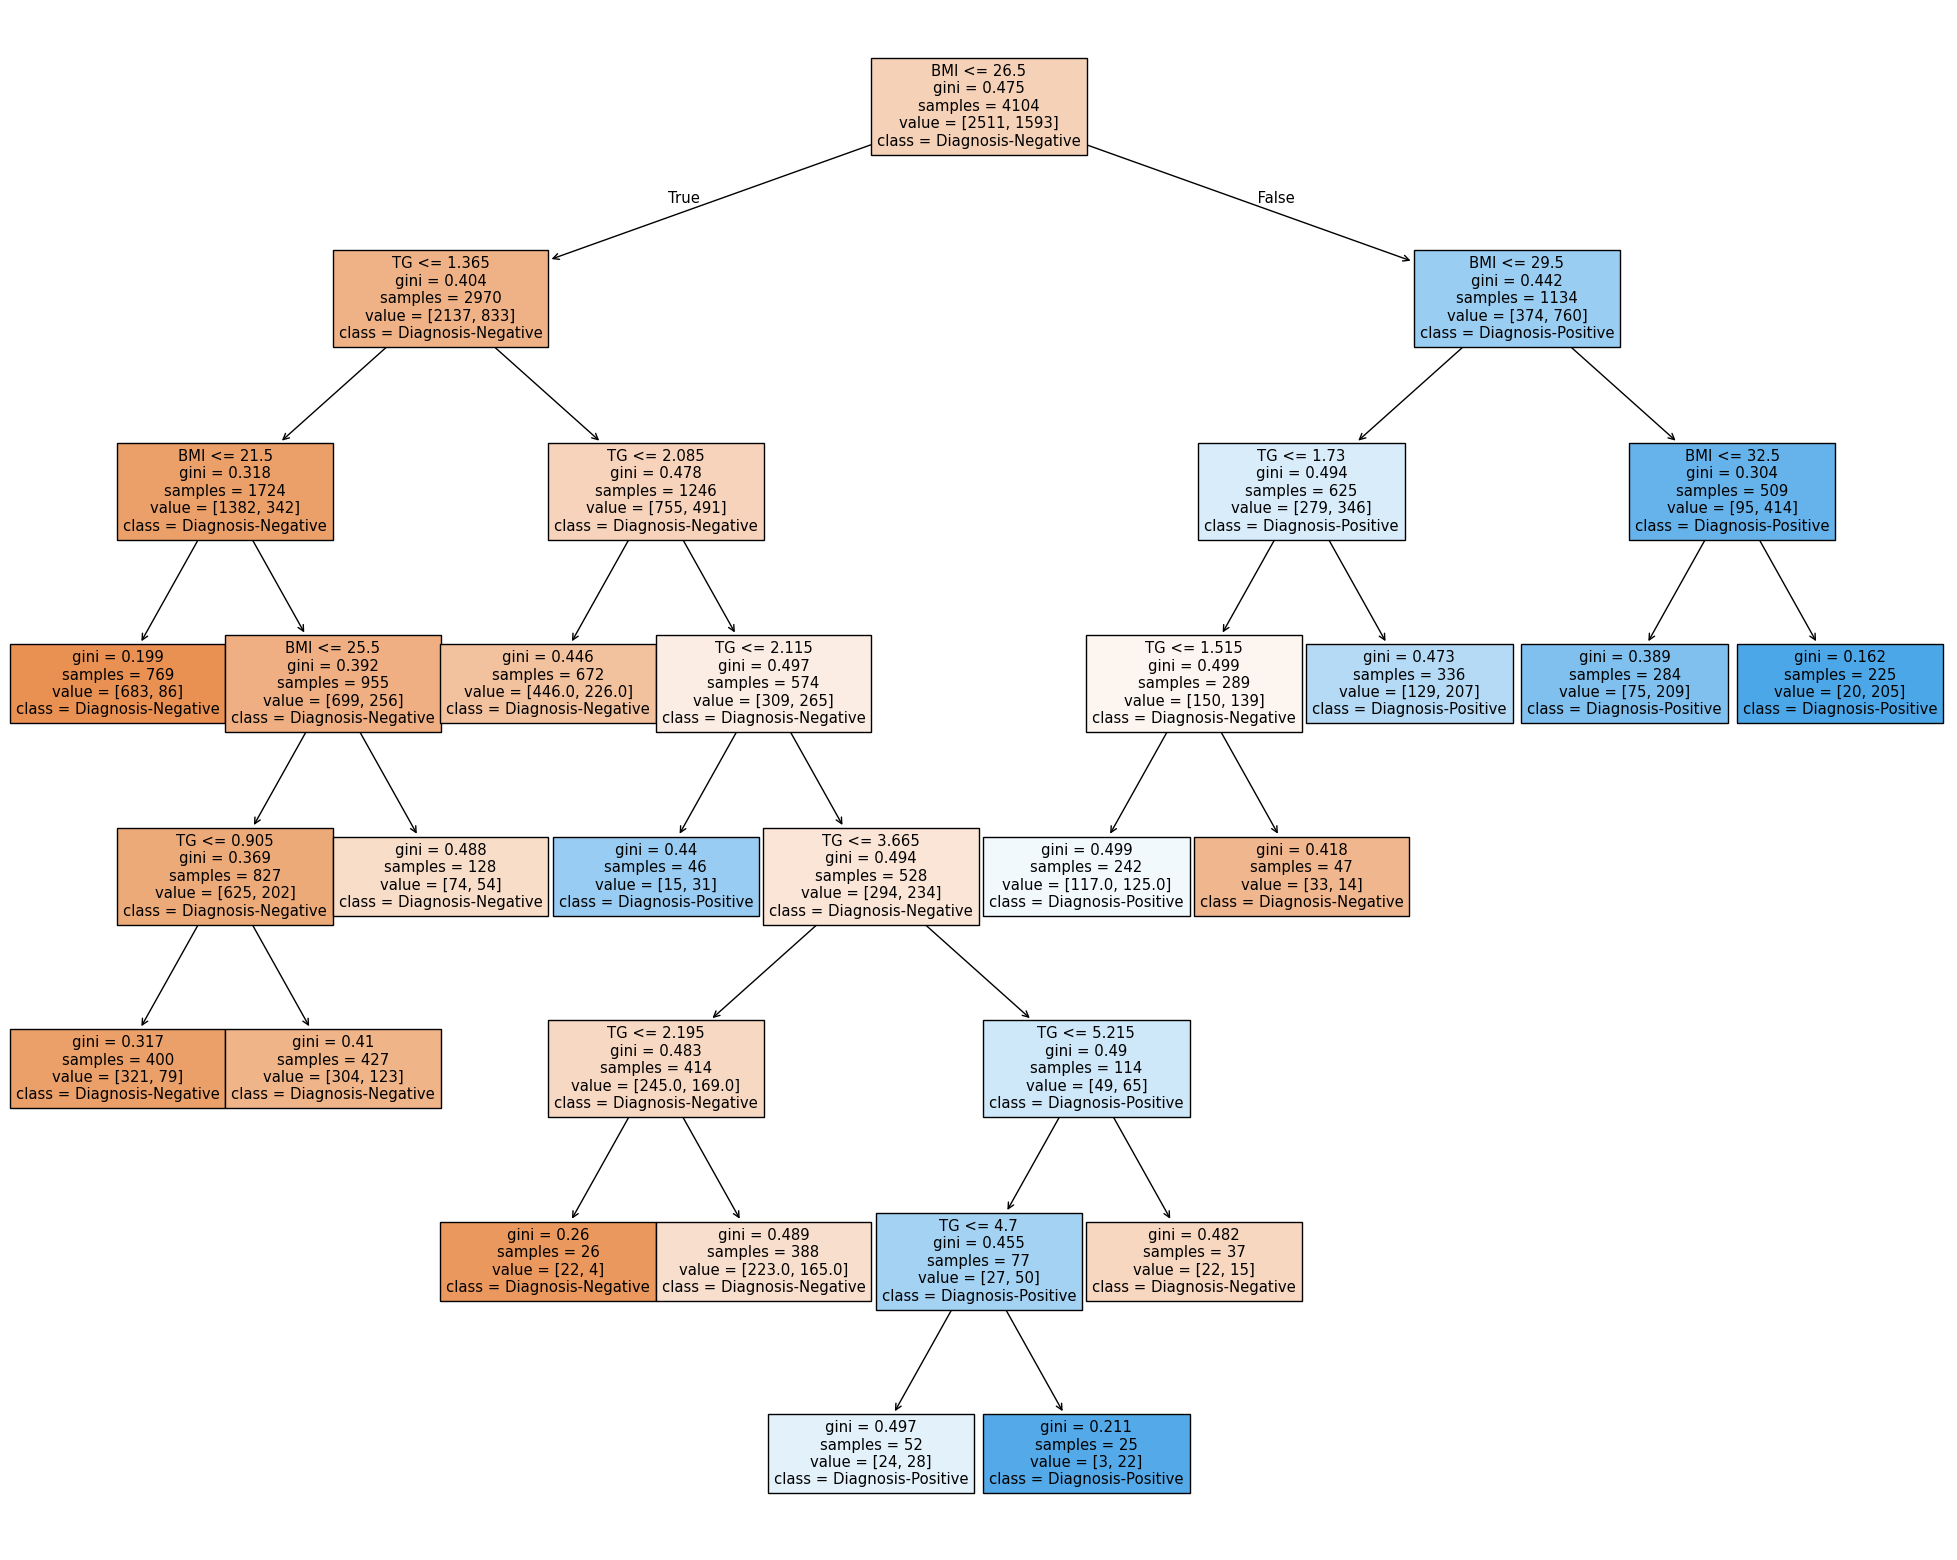

In [46]:
classifier = DecisionTreeClassifier(ccp_alpha=0.000782)
classifier.fit(X_train, y_train)
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(classifier, class_names=['Diagnosis-Negative','Diagnosis-Positive'],feature_names=['TG','BMI'], filled=True)
y_pred = classifier.predict(X_test)
print('Test Accuracy:', accuracy_score(y_test, y_pred))

LogisticRegression Accuracy Test

In [47]:
data_copy3=data.copy()
data_copy3

,Age,Gender,BMI,Chol,TG,HDL,LDL,Cr,BUN,Diagnosis
0,50,0.0,24,4.20,0.90,2.40,1.40,46.0,4.70,0
1,26,1.0,23,3.70,1.40,1.10,2.10,62.0,4.50,0
2,33,1.0,21,4.90,1.00,0.80,2.00,46.0,7.10,0
3,45,0.0,21,2.90,1.00,1.00,1.50,24.0,2.30,0
4,50,0.0,24,3.60,1.30,0.90,2.10,50.0,2.00,0
...,...,...,...,...,...,...,...,...,...,...
5127,54,1.0,23,5.00,1.50,1.24,2.98,77.0,3.50,1
5128,50,0.0,22,4.37,2.09,1.37,2.29,47.3,4.40,1
5129,67,1.0,24,3.89,1.38,1.14,2.17,70.6,4.73,1
5130,60,0.0,29,5.91,1.29,1.73,2.85,50.2,7.33,1


In [48]:
X = data_copy3.drop('Diagnosis',axis=1)
y = data_copy3['Diagnosis']

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)
scaler = preprocessing.StandardScaler()
scaler.fit(X_train)
X_trainStandard = scaler.transform(X_train)
X_testStandard = scaler.transform(X_test)

In [50]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
C_param_range = [0.001,0.01,0.1,1,10,100,1000,10000]
scoresCV = []
for c in C_param_range:
    logreg = LogisticRegression(C=c,penalty='l1',max_iter=1000,solver='liblinear')
    pipe = make_pipeline(preprocessing.StandardScaler(), logreg)
    scoreCV = cross_val_score(pipe, X_train, y_train, scoring='accuracy',
                             cv=KFold(n_splits=10, shuffle=True,
                                            random_state=1))
    scoresCV.append([c,np.mean(scoreCV)])

In [51]:
data_copy3 = pd.DataFrame(scoresCV,columns=['C (1/lambda)','Validation Accuracy'])
data_copy3

,C (1/lambda),Validation Accuracy
0,0.001,0.611854
1,0.010,0.811883
2,0.100,0.814315
3,1.000,0.816022
4,10.000,0.816023
5,100.000,0.815779
6,1000.000,0.816023
7,10000.000,0.816023


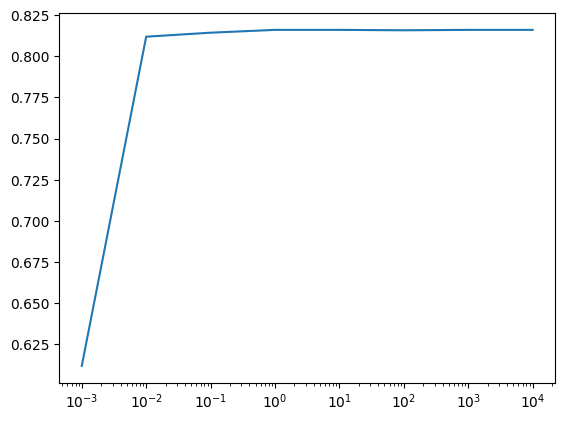

In [52]:
ax = plt.gca()
ax.plot(data_copy3['C (1/lambda)'].values,data_copy3['Validation Accuracy'].values)
ax.set_xscale('log')

In [53]:
logreg = LogisticRegression(C=10,penalty='l1',max_iter=1000,solver='liblinear')
logreg.fit(X_trainStandard, y_train)
score = logreg.score(X_testStandard, y_test)
print('Test Accuracy:', score)
Model_intercept = pd.DataFrame({"Variables":'Intercept',"Coefficients":logreg.intercept_[0]},index=[0])
Model_coefficients = pd.DataFrame({"Variables":X.columns,"Coefficients":np.transpose(logreg.coef_[0])})
Model_coefficients = pd.concat([Model_intercept,Model_coefficients]).reset_index(drop=True)
print(Model_coefficients)

Test Accuracy: 0.8120740019474196
   Variables  Coefficients
0  Intercept     -0.687495
1        Age      1.254242
2     Gender     -0.150408
3        BMI      1.045543
4       Chol     -0.266279
5         TG      0.359073
6        HDL      0.958903
7        LDL      0.196262
8         Cr     -0.240686
9        BUN      0.203833


4.Project Report

## Project Report

### Overview
This project predicts diabetes diagnosis from clinical blood and body
measurements. The dataset contains 5,131 patient records (one row was
dropped for missing gender) across 9 predictor variables: Age, Gender,
BMI, total cholesterol (Chol), triglycerides (TG), HDL, LDL, creatinine
(Cr), and blood urea nitrogen (BUN), with a binary diabetes Diagnosis.

### Data balance
38.8 percent of patients in the dataset have diabetes and 61.2 percent do
not. This matters because a model that simply guessed "no diabetes" every
time would already be right 61.2 percent of the time. Any model worth
keeping has to beat that baseline by a clear margin.

### Approach
I worked in three stages: data cleaning, exploratory analysis, and
predictive modelling.

During cleaning I removed one row with a missing gender value and dropped
an unused index column called Unnamed: 0. I then explored the
distributions of age, BMI, gender, and diagnosis, and looked at how BMI
and age relate to a positive diagnosis.

For modelling I tested and tuned three classifiers:

Logistic Regression reached 81.2 percent test accuracy, tuned with a C
grid search using 10 fold cross validation.

K Nearest Neighbors reached 79.5 percent, with k selected through 10 fold
cross validation.

Decision Tree reached 71.7 percent, tuned with cost complexity pruning.

### Why accuracy alone is not enough here
Because this predicts a serious disease, accuracy on its own is
misleading. A false negative, meaning the model tells a diabetic patient
they are healthy, is far more dangerous than a false positive. For that
reason I evaluated the model with a confusion matrix and looked
specifically at recall on the diabetes class, which measures how many
real diabetics the model actually caught. For a screening tool, missing
true cases is the failure that counts most.

### Conclusion
Logistic Regression performed best at 81.2 percent, comfortably above the
61.2 percent baseline. This is not accurate enough to replace clinical
testing, but a model at this level could work as an early warning screen.
Someone with routine blood work could receive a preliminary risk flag and
be encouraged to seek proper testing. Used that way, as a prompt to see a
doctor rather than a diagnosis, it could support earlier detection.